# Simple examples - Statistics

This notebook is just a small reference on how to request OSM statistics via the ohsome-API.

Statistics:
- features length for single timestamp
- features count for time series
- contributors count for time bins
- contributions count for time bins


In [2]:
import os
from io import StringIO

import httpx
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
OHSOME_API_URL = "https://api.heigit.org/ohsome-api/v2-rc"
OHSOME_API_KEY = os.environ["OHSOME_API_KEY"]  # insert your api key here

## Features Length Single Timestamp

In [3]:
response = httpx.post(
    OHSOME_API_URL + "/stats/features/length.csv",
    json={
        "aoi": [8.6275437, 49.3727921, 8.7545042, 49.4385023],
        "filter": "highway=residential and geometry:line",
        "time": "latest",
    },
    headers={"authorization": OHSOME_API_KEY},
)

df = pd.read_csv(
    StringIO(response.text),
    delimiter=";",
    header=3,  # skip first 3 rows with metadata
)

display(df)

,timestamp,value
0,2026-08-21T21:59:59Z,242452


## Features Count Time Series

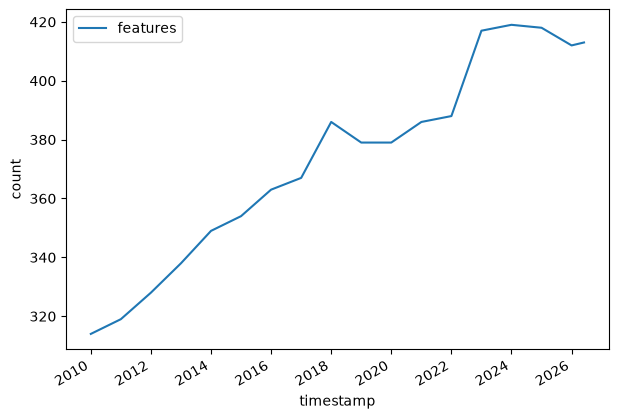

In [11]:
response = httpx.post(
    OHSOME_API_URL + "/stats/features/count.csv",
    json={
        "aoi": [8.6275437, 49.3727921, 8.7545042, 49.4385023],
        "filter": "highway=bus_stop and geometry:point",
        "time": {"start": "2010-01-01", "end": "2026-06-01", "interval": "P1Y"},
    },
    headers={"authorization": OHSOME_API_KEY},
)

df = pd.read_csv(
    StringIO(response.text),
    delimiter=";",
    header=3,  # skip first 3 rows with metadata
)

df["timestamp"] = pd.to_datetime(df["timestamp"])


fig, ax = plt.subplots(figsize=(7, 5))
df.plot("timestamp", "value", ax=ax, label="features", ylabel="count")
plt.show()

## Contributors Count Time Bins

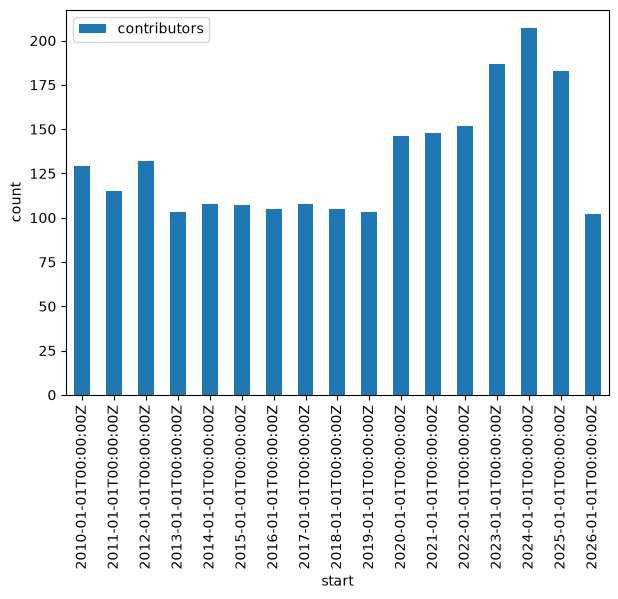

In [13]:
response = httpx.post(
    OHSOME_API_URL + "/stats/contributors/count.csv",
    json={
        "aoi": [8.6275437, 49.3727921, 8.7545042, 49.4385023],
        "filter": "highway=* and geometry:line",
        "time": {"start": "2010-01-01", "end": "2026-06-01", "binSize": "P1Y"},
    },
    headers={"authorization": OHSOME_API_KEY},
)

df = pd.read_csv(
    StringIO(response.text),
    delimiter=";",
    header=3,  # skip first 3 rows with metadata
)

fig, ax = plt.subplots(figsize=(7, 5))
df.plot(
    "start",
    "value",
    ax=ax,
    kind="bar",
    label="contributors",
    ylabel="count",
)
plt.show()

## Contributions Count Time Bins

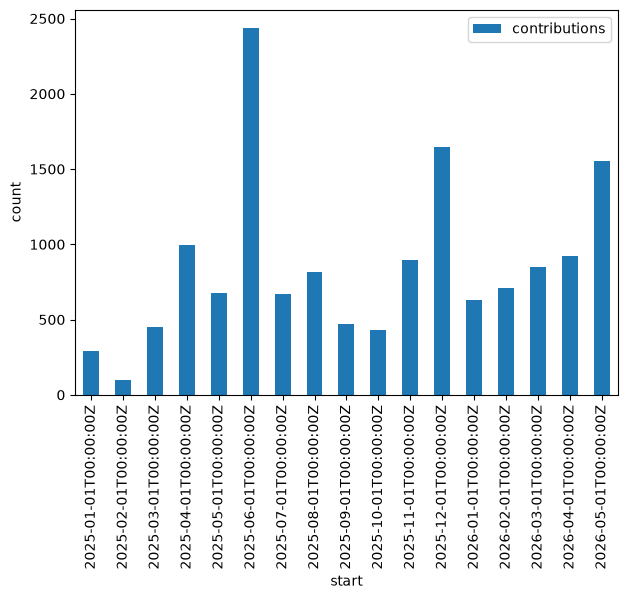

In [14]:
response = httpx.post(
    OHSOME_API_URL + "/stats/contributions/count.csv",
    json={
        "aoi": [8.6275437, 49.3727921, 8.7545042, 49.4385023],
        "filter": "building=* and geometry:polygon",
        "time": {"start": "2025-01-01", "end": "2026-06-01", "binSize": "P1M"},
    },
    headers={"authorization": OHSOME_API_KEY},
)

df = pd.read_csv(
    StringIO(response.text),
    delimiter=";",
    header=3,  # skip first 3 rows with metadata
)

fig, ax = plt.subplots(figsize=(7, 5))
df.plot("start", "value", ax=ax, kind="bar", label="contributions", ylabel="count")
plt.show()